# galaxy10 — a first look

before building any model it's worth knowing what the data actually *is*. Galaxy10
is 21,785 real SDSS galaxy images, hand-labelled into 10 morphology classes (round
smooth galaxies, edge-on disks, barred/unbarred spirals, and so on). each image is a
tiny 69x69x3 colour cutout — small enough that the whole set trains on a laptop CPU.

this notebook looks at three things that end up shaping every modelling decision later:
how balanced the classes are, what the images look like, and how bright/noisy they are.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

from galaxy_cnn.data import load_raw, CLASS_NAMES

images, labels = load_raw()
print("images:", images.shape, images.dtype)
print("labels:", labels.shape, "classes:", sorted(set(labels.tolist())))

images: (21785, 69, 69, 3) uint8
labels: (21785,) classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## how balanced are the classes?

the first thing that jumps out, and the single biggest modelling headache here.

  class 1  n= 6997   Smooth, Completely round
  class 2  n= 6292   Smooth, in-between round
  class 0  n= 3461   Disk, Face-on, No Spiral
  class 4  n= 1534   Disk, Edge-on, Rounded Bulge
  class 7  n= 1121   Disk, Face-on, Tight Spiral
  class 8  n=  906   Disk, Face-on, Medium Spiral
  class 6  n=  589   Disk, Edge-on, No Bulge
  class 9  n=  519   Disk, Face-on, Loose Spiral
  class 3  n=  349   Smooth, Cigar shaped
  class 5  n=   17   Disk, Edge-on, Boxy Bulge


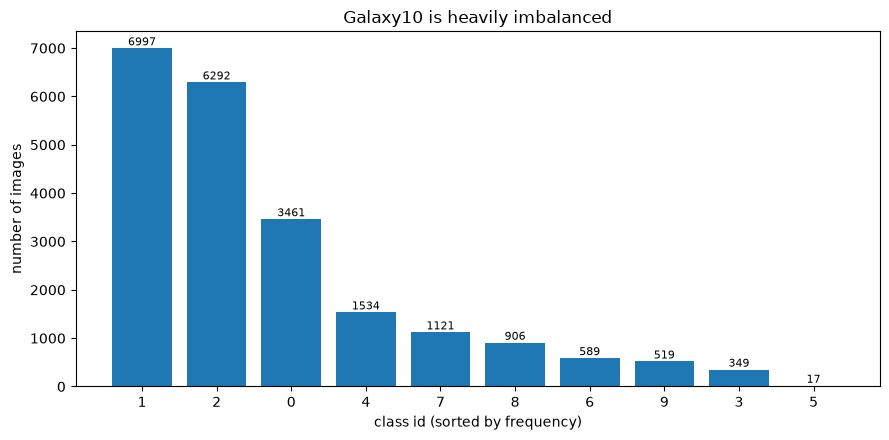

In [2]:
counts = np.bincount(labels, minlength=10)
order = np.argsort(counts)[::-1]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(10), counts[order], color="tab:blue")
ax.set_xticks(range(10))
ax.set_xticklabels([f"{i}" for i in order])
ax.set_xlabel("class id (sorted by frequency)")
ax.set_ylabel("number of images")
ax.set_title("Galaxy10 is heavily imbalanced")
for x, i in enumerate(order):
    ax.text(x, counts[i] + 60, str(counts[i]), ha="center", fontsize=8)
plt.tight_layout()

for i in order:
    print(f"  class {i}  n={counts[i]:5d}   {CLASS_NAMES[i]}")

the biggest class has ~7,000 images; the smallest ("Disk, Edge-on, Boxy Bulge") has
just **17**. that ~400:1 ratio means plain accuracy is a trap — a model that never once
predicts the rare classes can still score well overall. two consequences carried through
the rest of the project: the loss is **class-weighted** by inverse frequency, and models
are selected and reported on **macro-F1** (which averages the classes equally) rather than
raw accuracy.

## what do the galaxies look like?

a few random examples from each class. the labels are morphological — smooth blobs,
edge-on streaks, face-on spirals — and at 69 pixels some of the finer distinctions are
genuinely hard even for a human, which sets expectations for what a model can do.

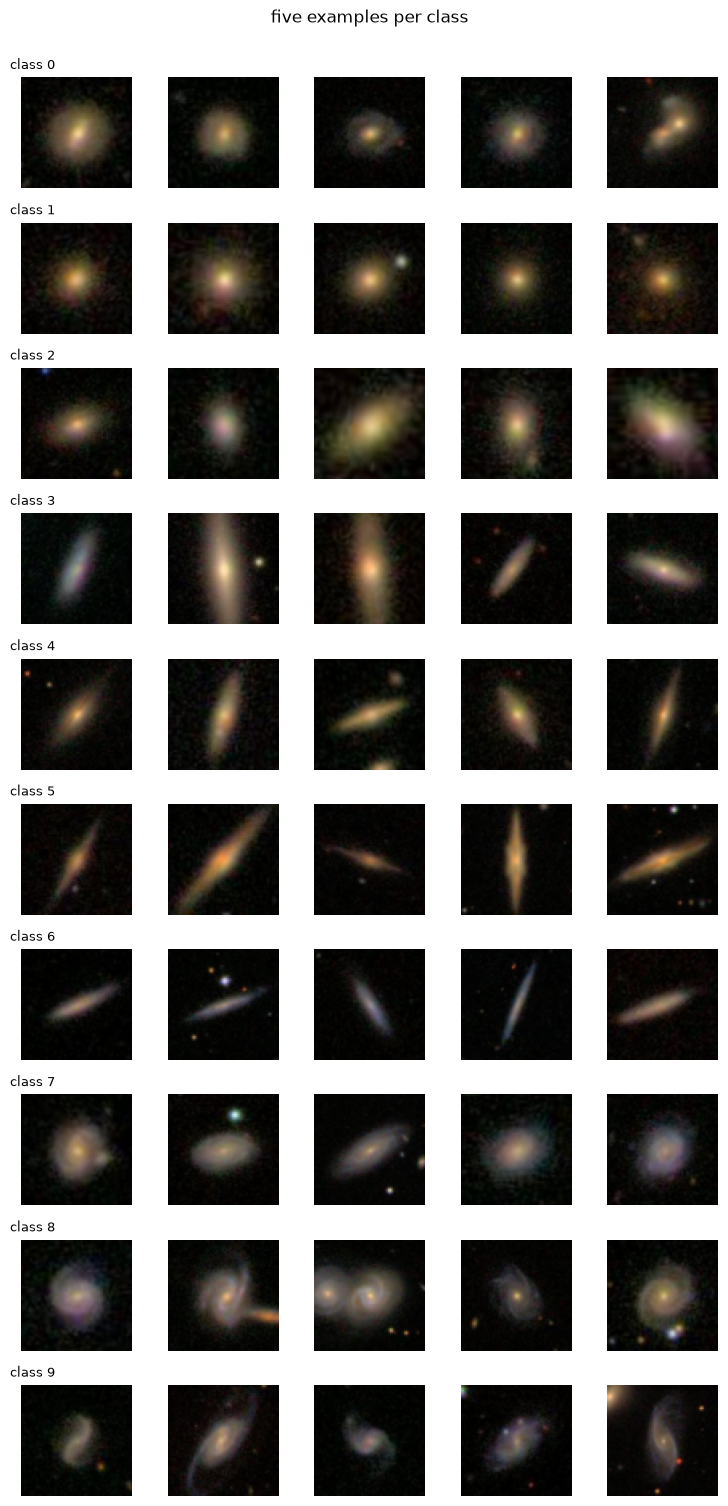

In [3]:
rng = np.random.default_rng(1)
n_show = 5
fig, axes = plt.subplots(10, n_show, figsize=(n_show * 1.5, 10 * 1.5))
for cls in range(10):
    idx = np.where(labels == cls)[0]
    pick = rng.choice(idx, size=min(n_show, len(idx)), replace=False)
    for j in range(n_show):
        ax = axes[cls, j]
        ax.axis("off")
        if j < len(pick):
            ax.imshow(images[pick[j]])
        if j == 0:
            ax.set_title(f"class {cls}", loc="left", fontsize=9, x=-0.1)
fig.suptitle("five examples per class", y=1.001)
plt.tight_layout()

## brightness and orientation

two quick sanity checks. the mean-intensity histogram shows the images are mostly dark
sky with a bright galaxy in the middle — useful for picking normalisation constants. and
because a galaxy can sit at *any* angle on the sky, orientation carries no information:
that's exactly why flips and rotations are safe, free data augmentation, which the training
pipeline leans on heavily.

channel means (0-1): [0.10863282 0.09342765 0.071147  ]


channel stds  (0-1): [0.14722046 0.12304152 0.10324825]


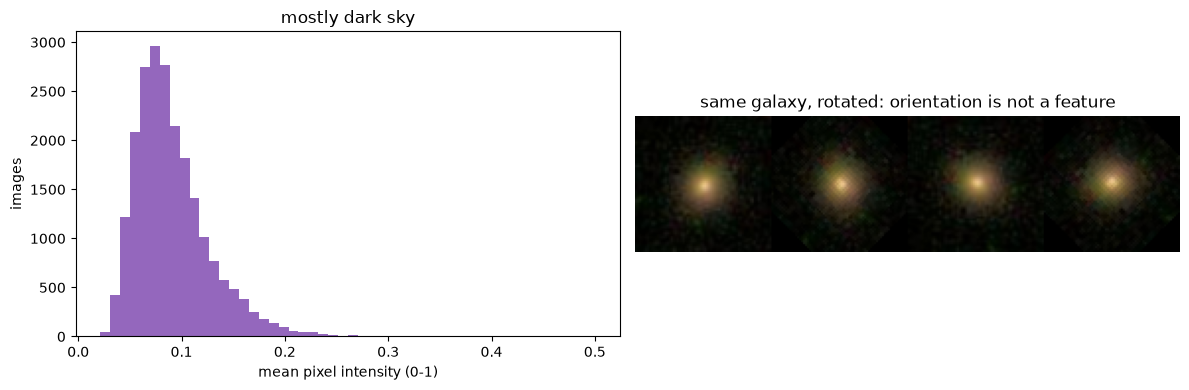

In [4]:
mean_intensity = images.reshape(len(images), -1).mean(axis=1) / 255.0

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(mean_intensity, bins=50, color="tab:purple")
ax[0].set_xlabel("mean pixel intensity (0-1)")
ax[0].set_ylabel("images")
ax[0].set_title("mostly dark sky")

# a single galaxy rotated a few ways — same label, different pixels
from PIL import Image
g = Image.fromarray(images[np.where(labels == order[0])[0][0]])
grid = np.hstack([np.asarray(g.rotate(a)) for a in (0, 45, 90, 135)])
ax[1].axis("off")
ax[1].imshow(grid)
ax[1].set_title("same galaxy, rotated: orientation is not a feature")
plt.tight_layout()

print(f"channel means (0-1): {images.reshape(-1,3).mean(0)/255}")
print(f"channel stds  (0-1): {images.reshape(-1,3).std(0)/255}")

## takeaways for modelling

- **imbalance is the main challenge** — handle it with class weights, judge with macro-F1.
- **images are small (69px) and low-detail** — a compact CNN is appropriate; we don't need
  a giant network, and for transfer learning we upsize modestly rather than to full 224.
- **orientation is meaningless** — flip/rotate augmentation multiplies the effective data
  for free, which especially helps the rare classes.

**in the real project:** `src/galaxy_cnn/data.py` turns these observations into code — the
stratified split (every class present in train/val/test), the inverse-frequency
`class_weights`, and the two augmentation pipelines.

**try it yourself:** merge the three "smooth" classes into one and see how much easier the
problem gets — a lot of the difficulty here is fine-grained distinctions between similar
morphologies, not galaxies-vs-noise.